In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from koala.pointsets import uniform
from koala.voronization import generate_lattice
from koala import graph_utils as gu
from koala import plotting as pl

from koala import example_graphs as eg
from koala.lattice import Lattice, _sorted_vertex_adjacent_edges

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

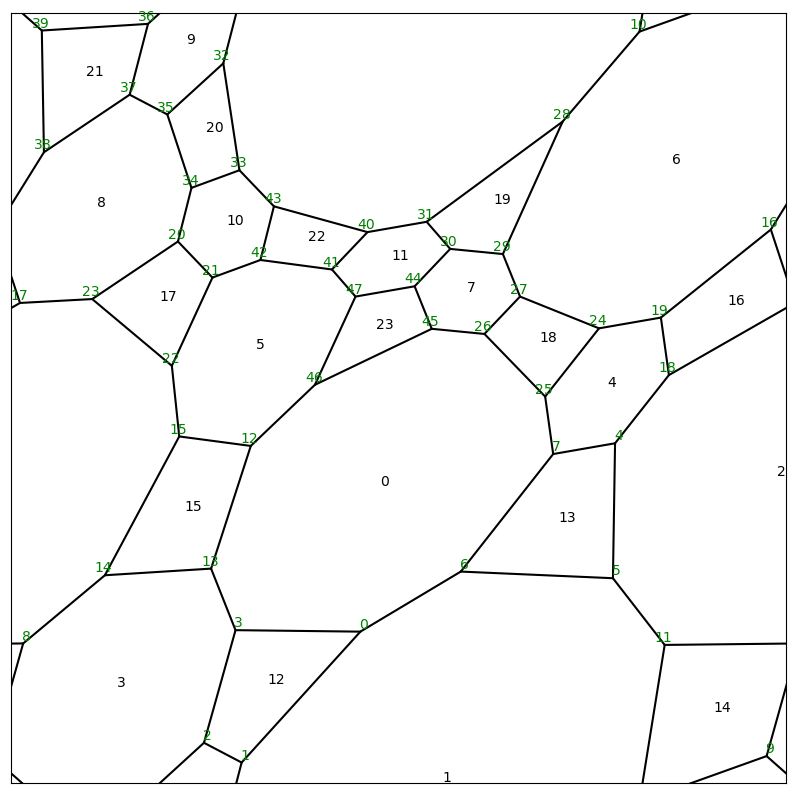

In [3]:
# generate a bipartite lattice
n_sites = 50

lattice = generate_lattice(uniform(n_sites // 4))
dimerisation = gu.dimerise(lattice)
lattice = gu.dimer_collapse(lattice, dimerisation)
lattice = gu.vertices_to_polygon(lattice)

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
pl.plot_edges(lattice)
pl.plot_vertex_indices(lattice, color="g")
pl.plot_plaquette_indices(lattice)
ax.set_xticks([])
ax.set_yticks([])
plt.show()

Text(0.5, 1.0, 'Flipped and relaxed')

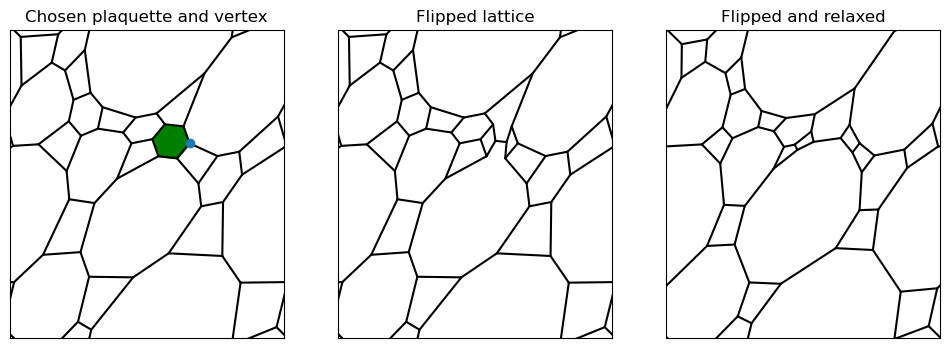

In [4]:
from koala.pachner_moves import bipartite_1_plus

# find a non-square:
p = 7
v = lattice.plaquettes[p].vertices[0]

l1plus = bipartite_1_plus(lattice, p, v)
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
for a in ax:
    a.set_xticks([])
    a.set_yticks([])

pl.plot_edges(lattice, ax=ax[0])
pl.plot_plaquettes(lattice, ax=ax[0], subset=[p], color_scheme="green")
ax[0].scatter(*lattice.vertices.positions[v], zorder=10)

pl.plot_edges(l1plus, ax=ax[1])
pl.plot_edges(gu.com_relaxation(l1plus), ax=ax[2])

ax[0].set_title("Chosen plaquette and vertex")
ax[1].set_title("Flipped lattice")
ax[2].set_title("Flipped and relaxed")

[ 1  1 -1 -1]


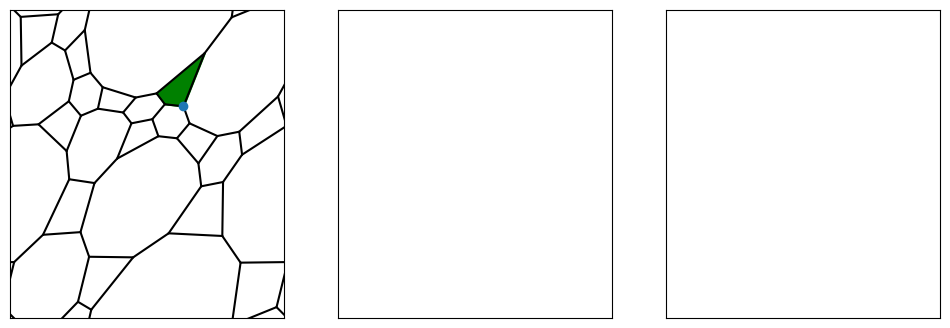

In [5]:
from koala.pachner_moves import bipartite_1_minus

# find a non-square:
p = 19
v = lattice.plaquettes[p].vertices[0]

l1minus = bipartite_1_minus(lattice, p, v)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
for a in ax:
    a.set_xticks([])
    a.set_yticks([])

pl.plot_edges(lattice, ax=ax[0])
pl.plot_plaquettes(lattice, ax=ax[0], subset=[p], color_scheme="green")
ax[0].scatter(*lattice.vertices.positions[v], zorder=10)

# pl.plot_edges(l1plus, ax=ax[1])
# pl.plot_edges(gu.com_relaxation(l1plus), ax=ax[2])

# ax[0].set_title("Chosen plaquette and vertex")
# ax[1].set_title("Flipped lattice")
# ax[2].set_title("Flipped and relaxed")